# Day 5 — Pretrained CNN comparison

Use torchvision feature extraction to compare toy CNN activations with a real pretrained model.

Official torchvision feature extraction docs: <https://docs.pytorch.org/vision/stable/feature_extraction.html>


## Scale reminder

The Day 3 model is intentionally tiny: it has only two convolution layers, with `6` then `16` feature maps, before the classifier. Its modest CIFAR-10 accuracy is expected because the images are only 32 by 32 pixels, the model has limited capacity, and the training run is short. The pretrained CNN is not a fair same-size comparison; it is here to show how the same feature-map idea scales to a larger, already-trained vision model.


In [2]:
import torch
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.models.feature_extraction import get_graph_node_names

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.eval()

train_nodes, eval_nodes = get_graph_node_names(model)

for node_name in eval_nodes:
    print(node_name)

x
conv1
bn1
relu
maxpool
layer1.0.conv1
layer1.0.bn1
layer1.0.relu
layer1.0.conv2
layer1.0.bn2
layer1.0.add
layer1.0.relu_1
layer1.1.conv1
layer1.1.bn1
layer1.1.relu
layer1.1.conv2
layer1.1.bn2
layer1.1.add
layer1.1.relu_1
layer2.0.conv1
layer2.0.bn1
layer2.0.relu
layer2.0.conv2
layer2.0.bn2
layer2.0.downsample.0
layer2.0.downsample.1
layer2.0.add
layer2.0.relu_1
layer2.1.conv1
layer2.1.bn1
layer2.1.relu
layer2.1.conv2
layer2.1.bn2
layer2.1.add
layer2.1.relu_1
layer3.0.conv1
layer3.0.bn1
layer3.0.relu
layer3.0.conv2
layer3.0.bn2
layer3.0.downsample.0
layer3.0.downsample.1
layer3.0.add
layer3.0.relu_1
layer3.1.conv1
layer3.1.bn1
layer3.1.relu
layer3.1.conv2
layer3.1.bn2
layer3.1.add
layer3.1.relu_1
layer4.0.conv1
layer4.0.bn1
layer4.0.relu
layer4.0.conv2
layer4.0.bn2
layer4.0.downsample.0
layer4.0.downsample.1
layer4.0.add
layer4.0.relu_1
layer4.1.conv1
layer4.1.bn1
layer4.1.relu
layer4.1.conv2
layer4.1.bn2
layer4.1.add
layer4.1.relu_1
avgpool
flatten
fc


In [3]:
from torchvision.models.feature_extraction import create_feature_extractor

return_nodes = {
    "conv1": "early_conv",
    "layer1": "layer1",
    "layer2": "layer2",
    "layer3": "layer3",
}

feature_extractor = create_feature_extractor(model, return_nodes=return_nodes)
feature_extractor.eval()

dummy_image = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    features = feature_extractor(dummy_image)

for name, activation in features.items():
    print(name, activation.shape)

early_conv torch.Size([1, 64, 112, 112])
layer1 torch.Size([1, 64, 56, 56])
layer2 torch.Size([1, 128, 28, 28])
layer3 torch.Size([1, 256, 14, 14])


## Read the activation shapes

The feature extractor returns activation tensors shaped `[batch, channels, height, width]`. In this dry run, the batch is `1` because we passed one image. The channel number is the number of feature maps produced by that ResNet stage, and the height/width numbers are the spatial grid size of each feature map.

```text
early_conv: [1,  64, 112, 112]
layer1:     [1,  64,  56,  56]
layer2:     [1, 128,  28,  28]
layer3:     [1, 256,  14,  14]
```

As the model goes deeper, the number of channels increases while the spatial dimensions shrink. This means ResNet trades exact location detail for a larger variety of learned signals. Early feature maps are usually more image-like and local; later feature maps are smaller grids that combine earlier responses into more abstract, harder-to-name patterns.

This is the same basic pattern as the tiny CNN, only scaled up: the tiny model went from `6` feature maps at `28 x 28` to `16` feature maps at `10 x 10`, while ResNet reaches hundreds of feature maps across several stages.


input batch: torch.Size([1, 3, 224, 224])
early_conv torch.Size([1, 64, 112, 112])
layer1 torch.Size([1, 64, 56, 56])
layer2 torch.Size([1, 128, 28, 28])
layer3 torch.Size([1, 256, 14, 14])


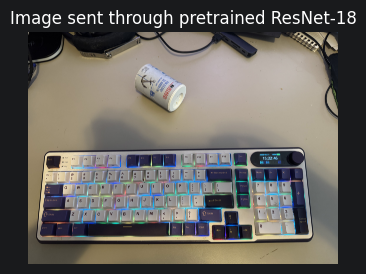

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

from cnn_feature_map_lab.paths import project_path

preprocess = weights.transforms()

image_path = project_path("data", "my_sample_image.jpg")
image = Image.open(image_path).convert("RGB")
input_batch = preprocess(image).unsqueeze(0)

with torch.no_grad():
    features = feature_extractor(input_batch)

print("input batch:", input_batch.shape)
for name, activation in features.items():
    print(name, activation.shape)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title("Image sent through pretrained ResNet-18")
plt.axis("off")
plt.show()

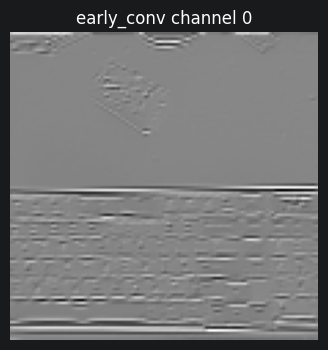

In [6]:
layer_name = "early_conv"
channel_index = 0

feature_map = features[layer_name][0, channel_index].detach().cpu()

plt.figure(figsize=(4, 4))
plt.imshow(feature_map, cmap="gray")
plt.title(f"{layer_name} channel {channel_index}")
plt.axis("off")
plt.show()

## Early activation observation

In `early_conv` channel `0`, the strongest responses seem to line up with vertical edges in the photo, such as keyboard key boundaries and other high-contrast object borders. This fits the usual CNN pattern: early convolution layers often learn local edge, color, and contrast detectors. The careful wording matters: this channel seems to respond to vertical edges, but that does not prove it detects a named object such as a keyboard.


Saved C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day05_pretrained_comparison\early_conv_selected_feature_maps.png


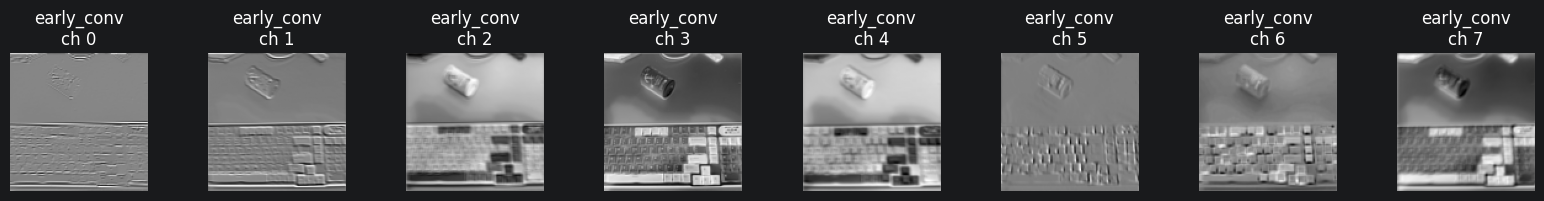

Saved C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day05_pretrained_comparison\layer2_selected_feature_maps.png


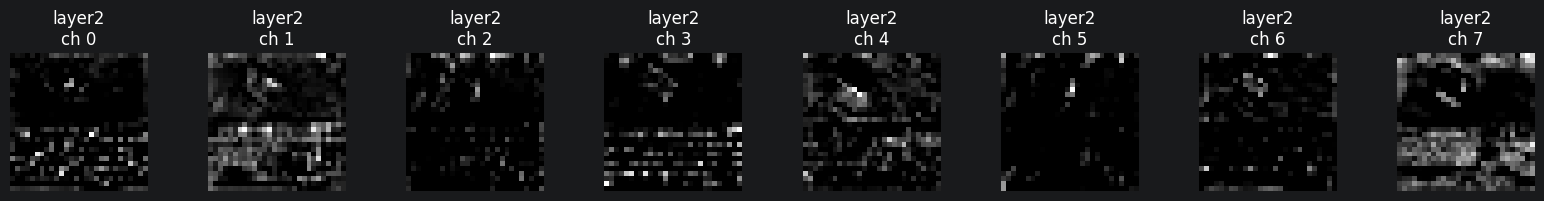

In [7]:
from cnn_feature_map_lab.visualization import normalize_feature_map

OUTPUT_DIR = project_path("outputs", "day05_pretrained_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show_activation_grid(
    features: dict[str, torch.Tensor],
    layer_name: str,
    channel_indices: list[int],
) -> None:
    activation = features[layer_name][0].detach().cpu()
    num_channels = len(channel_indices)

    fig, axes = plt.subplots(1, num_channels, figsize=(num_channels * 2, 2))

    for axis, channel_index in zip(axes, channel_indices, strict=True):
        feature_map = normalize_feature_map(activation[channel_index])
        axis.imshow(feature_map, cmap="gray")
        axis.set_title(f"{layer_name}\nch {channel_index}")
        axis.axis("off")

    output_path = OUTPUT_DIR / f"{layer_name}_selected_feature_maps.png"
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)

    print(f"Saved {output_path}")
    plt.show()
    plt.close(fig)


save_and_show_activation_grid(features, "early_conv", channel_indices=[0, 1, 2, 3, 4, 5, 6, 7])
save_and_show_activation_grid(features, "layer2", channel_indices=[0, 1, 2, 3, 4, 5, 6, 7])

## Early vs deeper pretrained activations

The selected `early_conv` channels look mostly like low-level responses: some channels emphasize color changes, and others emphasize edges or high-contrast boundaries. This is similar to the tiny CNN's first convolution layer, where the feature maps are still relatively easy to relate to visible image structure.

The selected `layer2` channels look more composed. Some activations seem to gather around individual keyboard-key regions rather than only raw edges. This suggests that deeper ResNet layers combine earlier color, edge, and spacing signals into more specific local structures. The careful wording is important: these maps look key-like in this image, but that does not prove the channels literally detect the concept `keyboard key`.

Toy-vs-pretrained comparison: both models show the same direction of change with depth, from simpler local responses toward more mixed and harder-to-name patterns. The pretrained ResNet shows this more strongly because it has many more channels, residual blocks, and training experience than the tiny CIFAR-10 CNN.


## Toy CNN vs pretrained ResNet comparison

Similarity: both the tiny CNN and pretrained ResNet show the same depth pattern. Earlier feature maps are easier to relate to visible image structure, while deeper feature maps become more mixed and harder to name.

Difference: the pretrained ResNet activations look richer and more varied. In `early_conv`, some channels respond to colors and edges; by `layer2`, some channels seem to activate around key-like regions. The tiny CNN has far fewer channels (`6` then `16`) and was trained briefly on low-resolution CIFAR-10, so its activations are simpler and noisier.

Conclusion: the toy CNN is useful for learning the mechanics of filters, pooling, and feature maps. The pretrained ResNet shows the same feature-map idea at a larger, more capable scale.


## Final note

Write your 5-10 sentence explanation of what feature maps are and how convolution/pooling/layers transform them.
